# Subgroup Analysis

Coco Yu  
October 15, 2024

# Housekeeping

## Code status

## Notes

# Set Up

## Set Up Environment

### Study parameters

In [ ]:
study <- params$study
cv <- params$cv
algorithms <- params$algorithms
version <- params$version

### Defaults

In [ ]:
#| message: false
#| warning: false

# handle conflicts
options(conflicts.policy = "depends.ok")
devtools::source_url("https://github.com/jjcurtin/lab_support/blob/main/fun_ml.R?raw=true")

ℹ SHA-1 hash of file is "77e91675366f10788c6bcb59fa1cfc9ee0c75281"

### Packages for script

In [ ]:
#| message: false
#| warning: false

library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.3     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──
✔ broom        1.0.5     ✔ rsample      1.2.0
✔ dials        1.2.0     ✔ tune         1.1.2
✔ infer        1.0.5     ✔ workflows    1.1.3
✔ modeldata    1.2.0     ✔ workflowsets 1.0.1
✔ parsnip      1.1.1     ✔ yardstick    1.2.0
✔ recipes      1.0.8     
── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()
• Use suppressPackageStartupMessages() to eliminate package startup messages

ℹ SHA-1 hash of file is "a58e57da996d1b70bb9a5b58241325d6fd78890f"

### Absolute paths

In [ ]:
path_models <- format_path(str_c("studydata/risk/models/", study))
path_messages <- format_path(str_c("studydata/risk/data_processed/messages"))
path_shared <- format_path(str_c("studydata/risk/data_processed/shared"))

## Data Cleaning

Read in Data

In [ ]:
probs <- # read_csv(here::here(path_models, str_c("inner_metrics_", version, "_", cv, ".csv"))) |> 
  read_rds(here::here(path_models, str_c("inner_preds_", version, "_", cv, ".rds"))) |> 
  #pivot_longer(cols = starts_with("prob"), 
               #names_to = "method", 
               #values_to = ".pred_Lapse") |>
  glimpse()

Rows: 312,174
Columns: 7
$ id_obs          <int> 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 612,…
$ outer_split_num <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ inner_split_num <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ prob_raw        <dbl> 0.5004720, 0.4995192, 0.4995192, 0.5005576, 0.5005382,…
$ prob_iso        <dbl> 0.07657658, 0.07657658, 0.07657658, 0.07657658, 0.0765…
$ prob_logi       <dbl> 0.09117982, 0.09939817, 0.09939817, 0.09293282, 0.0923…
$ label           <fct> no lapse, no lapse, no lapse, no lapse, no lapse, no l…

Rows: 208
Columns: 16
$ dem_1   <dbl> 57, 35, 22, 39, 22, 38, 22, 38, 25, 45, 63, 50, 53, 26, 52, 54…
$ dem_2   <chr> "Male", "Female", "Female", "Male", "Male", "Male", "Female", …
$ dem_3   <chr> "White/Caucasian", "White/Caucasian", "White/Caucasian", "Whit…
$ dem_3_1 <chr> NA, NA, NA, NA, NA, NA, NA, NA, "Filipino and Black", NA, NA, …
$ dem_4   <chr> "No, I am not of Hispanic, Latino, or Spanish origin", "No, I …
$ dem_4_1 <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ dem_5   <chr> "College degree", "2-Year degree", "High school or GED", "Coll…
$ dem_6   <chr> "Unemployed", "Employed", "Employed", "Employed", "Employed", …
$ dem_6_1 <chr> NA, "Full-time", "Full-time", "Full-time", "Part-time", "Full-…
$ dem_7   <dbl> 12000, 36920, 20064, 130000, 5000, 70000, 8000, 57000, 10000, …
$ dem_8   <chr> "Never Married", "Never Married", "Never Married", "Married", …
$ dem2_2  <dbl> 2, 2, 4, 1, 2, 1, 4, 2, 2, 2, 0, 2, 3, 2, 1, 0, 2, 2, 2, 1, 2,…
$ dem2_4  <dbl> 0,

Find demographic groups

In [ ]:
demographics <- labels |> 
  left_join(screen, by = "subid") |> 
  select(-day_start, -day_end, -lapse) |> 
  distinct() |>
  mutate(
    race = case_when(
      dem_3 == "White/Caucasian" & grepl("No", dem_4) ~ "white",
      dem_3 != "White/Caucasian" | grepl("Yes", dem_4) ~ "non_white"),
    sex = if_else(dem_2 == "Female", "female", "male"),
    age = if_else(dem_1 >= 55, "older", "younger"),
    income = if_else(dem_7 <= .5 * 30000, "below_poverty", "above_poverty")
  ) |> 
  select(-starts_with("dem")) |> 
  glimpse()

Rows: 11,562
Columns: 6
$ subid  <dbl> 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, …
$ id_obs <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, …
$ race   <chr> "white", "white", "white", "white", "white", "white", "white", …
$ sex    <chr> "female", "female", "female", "female", "female", "female", "fe…
$ age    <chr> "younger", "younger", "younger", "younger", "younger", "younger…
$ income <chr> "above_poverty", "above_poverty", "above_poverty", "above_pover…

In [ ]:
probs <- probs |> 
  left_join(demographics, by = "id_obs")

### Calculate auROC

In [ ]:
auroc_all <- probs |> 
  group_by(inner_split_num, outer_split_num) |> 
  summarize(auroc = roc_auc_vec(truth = label, estimate = prob_raw))

`summarise()` has grouped output by 'inner_split_num'. You can override using
the `.groups` argument.

In [ ]:
auroc_race <- probs |> 
  group_by(inner_split_num, outer_split_num, race) |> 
  summarize(auroc = roc_auc(cur_data(), prob_raw, truth = label)$.estimate) |> 
  ungroup() |> 
  bind_rows(auroc_all |> mutate(race = "all")) |> 
  rename(subgroup = race)

The first warning was:
ℹ In argument: `auroc = roc_auc(cur_data(), prob_raw, truth =
  label)$.estimate`.
ℹ In group 1: `inner_split_num = 1`, `outer_split_num = 1`, `race =
  "non_white"`.
Caused by warning:
! `cur_data()` was deprecated in dplyr 1.1.0.
ℹ Please use `pick()` instead.
ℹ Run `dplyr::last_dplyr_warnings()` to see the 51 remaining warnings.

`summarise()` has grouped output by 'inner_split_num', 'outer_split_num'. You
can override using the `.groups` argument.

`summarise()` has grouped output by 'inner_split_num', 'outer_split_num'. You
can override using the `.groups` argument.

The first warning was:
ℹ In argument: `auroc = roc_auc(cur_data(), prob_raw, truth =
  label)$.estimate`.
ℹ In group 7: `inner_split_num = 1`, `outer_split_num = 4`, `age = "older"`.
Caused by warning:
! No event observations were detected in `truth` with event level 'lapse'.
ℹ Run `dplyr::last_dplyr_warnings()` to see the 64 remaining warnings.

`summarise()` has grouped output by 'inner_split_num', 'outer_split_num'. You
can override using the `.groups` argument.

The first warning was:
ℹ In argument: `auroc = roc_auc(cur_data(), prob_raw, truth =
  label)$.estimate`.
ℹ In group 166: `inner_split_num = 3`, `outer_split_num = 23`, `income =
  "below_poverty"`.
Caused by warning:
! No event observations were detected in `truth` with event level 'lapse'.
ℹ Run `dplyr::last_dplyr_warnings()` to see the 9 remaining warnings.

`summarise()` has grouped output by 'inner_split_num', 'outer_split_num'. You
can override using the `.groups` argument.

## Model Comparison

In [ ]:
contrast_table <- function(df, levels){
  df |> 
    filter(subgroup != "all") |>
    select(c("auroc", "subgroup", "inner_split_num", "outer_split_num")) |> 
    group_by(subgroup) |>
    mutate(repeat_num = inner_split_num,
           fold_num = outer_split_num) |> 
    select(c("auroc", "subgroup", "repeat_num", "fold_num")) |>
    pivot_wider(values_from = c("auroc"), names_from = subgroup) |>
    rename(id = repeat_num, id2 = fold_num) |>
    perf_mod(formula = statistic ~ model + (1 | id2/id),
             # prior_intercept = rstanarm::student_t(autoscale = TRUE),
             # prior = rstanarm::student_t(autoscale = TRUE),
             # transform = tidyposterior::logit_trans,  # for skewed & bounded AUC
             # iter = 2000, chains = 4,
             adapt_delta = .99,
             # cores = 4, seed = 12345,
             family = gaussian, verbose = FALSE) |> 
    contrast_models(list_1 = levels[1], list_2 = levels[2]) |> 
    summary(size = 0) |> 
    mutate(metrics = "auroc", .before = contrast)
  }

In [ ]:
contrast_table(auroc_race, c("white", "non_white"))


SAMPLING FOR MODEL 'continuous' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 8.4e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.84 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 5.957 seconds (Warm-up)
Chain 1:                1.986 seconds (Sampling)
Chain 1:                7.94

# A tibble: 1 × 10
  metrics contrast           probability   mean  lower  upper  size pract_neg
  <chr>   <chr>                    <dbl>  <dbl>  <dbl>  <dbl> <dbl>     <dbl>
1 auroc   white vs non_white       0.995 0.0315 0.0107 0.0522     0        NA
  pract_equiv pract_pos
        <dbl>     <dbl>
1          NA        NA


SAMPLING FOR MODEL 'continuous' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 4.9e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.49 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 8.201 seconds (Warm-up)
Chain 1:                2.172 seconds (Sampling)
Chain 1:                10.3

# A tibble: 1 × 10
  metrics contrast       probability   mean   lower  upper  size pract_neg
  <chr>   <chr>                <dbl>  <dbl>   <dbl>  <dbl> <dbl>     <dbl>
1 auroc   male vs female       0.992 0.0245 0.00821 0.0404     0        NA
  pract_equiv pract_pos
        <dbl>     <dbl>
1          NA        NA


SAMPLING FOR MODEL 'continuous' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 4.5e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.45 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 4.966 seconds (Warm-up)
Chain 1:                1.791 seconds (Sampling)
Chain 1:                6.75

# A tibble: 1 × 10
  metrics contrast         probability   mean  lower  upper  size pract_neg
  <chr>   <chr>                  <dbl>  <dbl>  <dbl>  <dbl> <dbl>     <dbl>
1 auroc   younger vs older        1.00 0.0405 0.0186 0.0625     0        NA
  pract_equiv pract_pos
        <dbl>     <dbl>
1          NA        NA


SAMPLING FOR MODEL 'continuous' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 4.4e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.44 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 6.469 seconds (Warm-up)
Chain 1:                2.708 seconds (Sampling)
Chain 1:                9.17

# A tibble: 1 × 10
  metrics contrast                       probability   mean   lower  upper  size
  <chr>   <chr>                                <dbl>  <dbl>   <dbl>  <dbl> <dbl>
1 auroc   above_poverty vs below_poverty       0.992 0.0244 0.00786 0.0411     0
  pract_neg pract_equiv pract_pos
      <dbl>       <dbl>     <dbl>
1        NA          NA        NA

Plots

In [ ]:
auroc_plot <- auroc_race |> 
  mutate(group = "race") |> 
  bind_rows(auroc_sex |> mutate(group = "sex")) |> 
  bind_rows(auroc_age |> mutate(group = "age")) |> 
  bind_rows(auroc_income |> mutate(group = "income"))

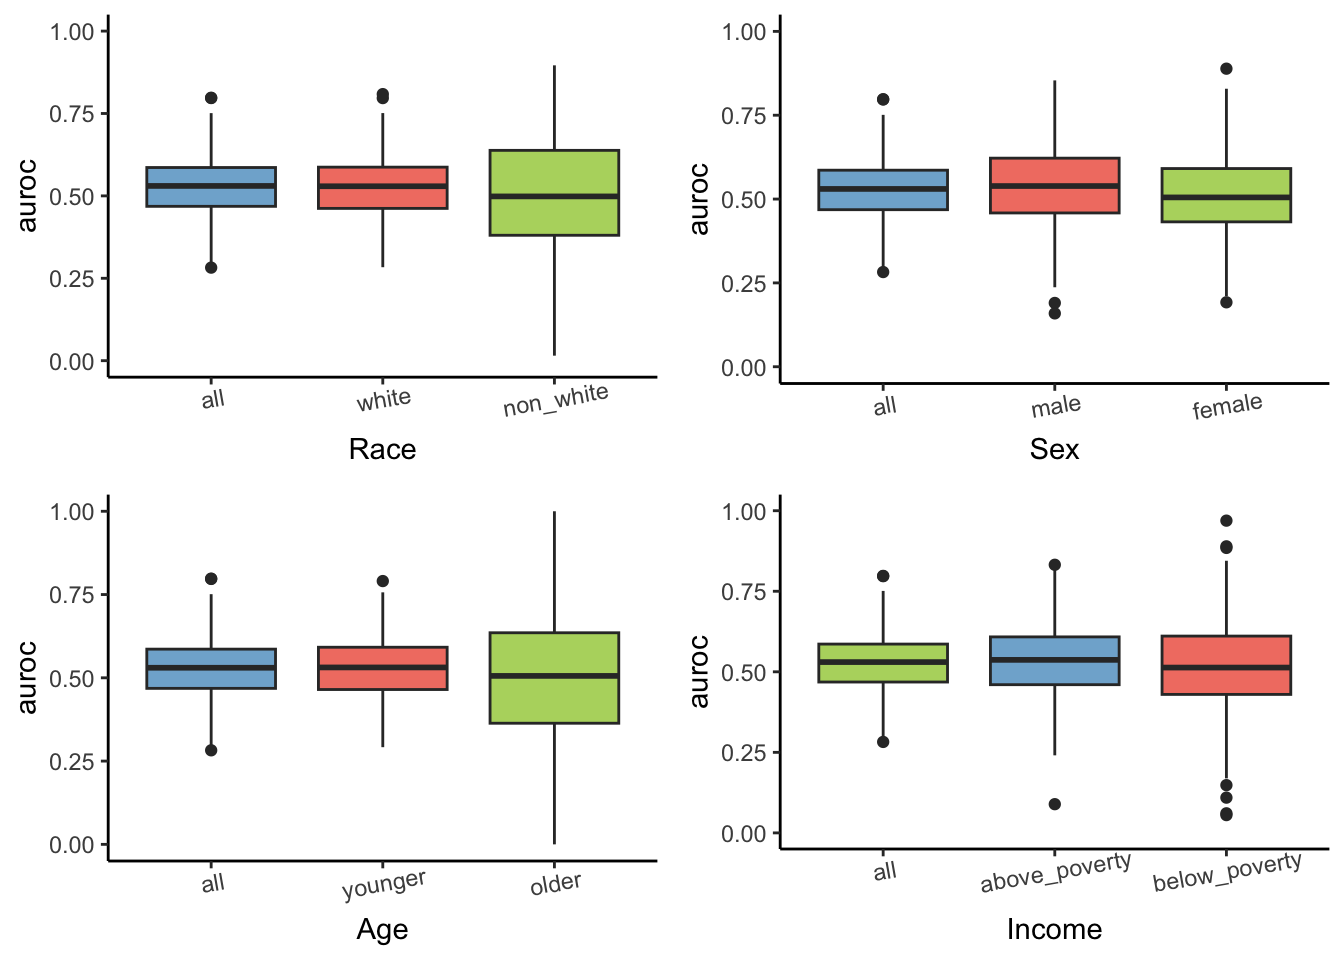

In [ ]:
#| label: fig-fairness
#| fig-cap: "auROC scores across different privileged vs. unprivileged groups"
#| fig-width: 7
#| fig-height: 5
ggpubr::ggarrange(
  auroc_race |> 
    ggplot(aes(x = factor(subgroup, levels = c("all", "white", "non_white")), 
               y = auroc, fill = subgroup)) +
    geom_boxplot() +
    theme(legend.position = "none", axis.text.x = element_text(angle = 10)) +
    scale_fill_manual(values = c("#80B1D3", "#B5D66E", "#F28072")) +
    ylim(0, 1) +
    labs(x = "Race"),
  auroc_sex |> 
    ggplot(aes(x = factor(subgroup, levels = c("all", "male", "female")),
               y = auroc, fill = subgroup)) +
    geom_boxplot() +
    theme(legend.position = "none", axis.text.x = element_text(angle = 10)) +
    scale_fill_manual(values = c("#80B1D3", "#B5D66E", "#F28072")) +
    ylim(0, 1) +
    labs(x = "Sex"),
  auroc_age |> 
    ggplot(aes(x = factor(subgroup, levels = c("all", "younger", "older")),
               y = auroc, fill = subgroup)) +
    geom_boxplot() +
    theme(legend.position = "none", axis.text.x = element_text(angle = 10)) +
    scale_fill_manual(values = c("#80B1D3", "#B5D66E", "#F28072")) +
    ylim(0, 1) +
    labs(x = "Age"),
  auroc_income |> 
    ggplot(aes(x = factor(subgroup, levels = 
                            c("all", "above_poverty", "below_poverty")),
               y = auroc, fill = subgroup)) +
    geom_boxplot() +
    theme(legend.position = "none", axis.text.x = element_text(angle = 10)) +
    scale_fill_manual(values = c("#80B1D3", "#B5D66E", "#F28072")) +
    ylim(0, 1) +
    labs(x = "Income")
)